In [66]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
sns.set(style="ticks")

In [67]:
data = pd.read_csv('healthcare-dataset-stroke-data.csv', sep=",")

### data.shape

In [68]:
data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [69]:
data.dtypes

id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

In [70]:
total_count = data.shape[0]
print('Всего строк: {}'.format(total_count))

Всего строк: 5110


In [71]:
data['smoking_status'].replace(['N/A', 'Unknown'], np.nan, inplace=True)


/var/folders/5x/lbd8871x0gg1k9cphlmq52500000gn/T/ipykernel_24117/374067912.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['smoking_status'].replace(['N/A', 'Unknown'], np.nan, inplace=True)


In [72]:
data.isnull().sum()

id                      0
gender                  0
age                     0
hypertension            0
heart_disease           0
ever_married            0
work_type               0
Residence_type          0
avg_glucose_level       0
bmi                   201
smoking_status       1544
stroke                  0
dtype: int64

In [73]:
# Удаление колонок, содержащих пустые значения
data_new_1 = data.dropna(axis=1, how='any')
(data.shape, data_new_1.shape)

((5110, 12), (5110, 10))

In [74]:
# Удаление строк, содержащих пустые значения
data_new_2 = data.dropna(axis=0, how='any')
(data.shape, data_new_2.shape)

((5110, 12), (3426, 12))

In [75]:
# Заполнение всех пропущенных значений нулями
# В данном случае это некорректно, так как нулями заполняются в том числе категориальные колонки
data_new_3 = data.fillna(0)
data_new_3.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,0.0,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [76]:
# Выберем числовые колонки с пропущенными значениями
# Цикл по колонкам датасета
num_cols = []
for col in data.columns:
    # Количество пустых значений 
    temp_null_count = data[data[col].isnull()].shape[0]
    dt = str(data[col].dtype)
    if temp_null_count>0 and (dt=='float64' or dt=='int64'):
        num_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))

Колонка bmi. Тип данных float64. Количество пустых значений 201, 3.93%.


In [77]:
# Фильтр по колонкам с пропущенными значениями
data_num = data[num_cols]
data_num

,bmi
0,36.6
1,NaN
2,32.5
3,34.4
4,24.0
...,...
5105,NaN
5106,40.0
5107,30.6
5108,25.6


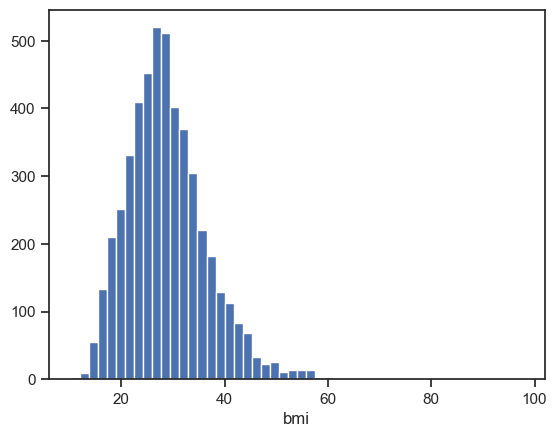

In [78]:
# Гистограмма по признакам
for col in data_num:
    plt.hist(data[col], 50)
    plt.xlabel(col)
    plt.show()

In [79]:
data_num_bmi = data_num[['bmi']]
data_num_bmi.head()

,bmi
0,36.6
1,NaN
2,32.5
3,34.4
4,24.0


In [80]:
from sklearn.impute import SimpleImputer
from sklearn.impute import MissingIndicator

In [81]:
# Фильтр для проверки заполнения пустых значений
indicator = MissingIndicator()
mask_missing_values_only = indicator.fit_transform(data_num_bmi)
mask_missing_values_only

array([[False],
       [ True],
       [False],
       ...,
       [False],
       [False],
       [False]])

In [82]:
strategies=['mean', 'median', 'most_frequent']

In [83]:
def test_num_impute(strategy_param):
    imp_num = SimpleImputer(strategy=strategy_param)
    data_num_imp = imp_num.fit_transform(data_num_bmi)
    return data_num_imp[mask_missing_values_only]

In [84]:
strategies[0], test_num_impute(strategies[0])

('mean',
 array([28.89323691, 28.89323691, 28.89323691, 28.89323691, 28.89323691,
        28.89323691, 28.89323691, 28.89323691, 28.89323691, 28.89323691,
        28.89323691, 28.89323691, 28.89323691, 28.89323691, 28.89323691,
        28.89323691, 28.89323691, 28.89323691, 28.89323691, 28.89323691,
        28.89323691, 28.89323691, 28.89323691, 28.89323691, 28.89323691,
        28.89323691, 28.89323691, 28.89323691, 28.89323691, 28.89323691,
        28.89323691, 28.89323691, 28.89323691, 28.89323691, 28.89323691,
        28.89323691, 28.89323691, 28.89323691, 28.89323691, 28.89323691,
        28.89323691, 28.89323691, 28.89323691, 28.89323691, 28.89323691,
        28.89323691, 28.89323691, 28.89323691, 28.89323691, 28.89323691,
        28.89323691, 28.89323691, 28.89323691, 28.89323691, 28.89323691,
        28.89323691, 28.89323691, 28.89323691, 28.89323691, 28.89323691,
        28.89323691, 28.89323691, 28.89323691, 28.89323691, 28.89323691,
        28.89323691, 28.89323691, 28.89323

In [85]:
strategies[1], test_num_impute(strategies[1])

('median',
 array([28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1,
        28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1,
        28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1,
        28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1,
        28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1,
        28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1,
        28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1,
        28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1,
        28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1,
        28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1,
        28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1,
        28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1,
        28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1, 28.1,
        28.1, 28.1, 28.1, 2

### strategies[2], test_num_impute(strategies[2])

In [86]:
# Выберем категориальные колонки с пропущенными значениями
# Цикл по колонкам датасета
cat_cols = []
for col in data.columns:
    # Количество пустых значений 
    temp_null_count = data[data[col].isnull()].shape[0]
    dt = str(data[col].dtype)
    if temp_null_count>0 and (dt=='object'):
        cat_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))

Колонка smoking_status. Тип данных object. Количество пустых значений 1544, 30.22%.


In [87]:
cat_temp_data = data[['smoking_status']]
cat_temp_data.head()

,smoking_status
0,formerly smoked
1,never smoked
2,never smoked
3,smokes
4,never smoked


In [88]:
cat_temp_data['smoking_status'].unique()

array(['formerly smoked', 'never smoked', 'smokes', nan], dtype=object)

In [89]:
cat_temp_data[cat_temp_data['smoking_status'].isnull()].shape

(1544, 1)

In [90]:
# Импьютация наиболее частыми значениями
imp2 = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
data_imp2 = imp2.fit_transform(cat_temp_data)
data_imp2

array([['formerly smoked'],
       ['never smoked'],
       ['never smoked'],
       ...,
       ['never smoked'],
       ['formerly smoked'],
       ['never smoked']], dtype=object)

In [91]:
# Пустые значения отсутствуют
np.unique(data_imp2)

array(['formerly smoked', 'never smoked', 'smokes'], dtype=object)

In [92]:
# Импьютация константой
imp3 = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='NA')
data_imp3 = imp3.fit_transform(cat_temp_data)
data_imp3

array([['formerly smoked'],
       ['never smoked'],
       ['never smoked'],
       ...,
       ['never smoked'],
       ['formerly smoked'],
       ['NA']], dtype=object)

In [93]:
np.unique(data_imp3)

array(['NA', 'formerly smoked', 'never smoked', 'smokes'], dtype=object)

In [94]:
data_imp3[data_imp3=='NA'].size

1544

In [95]:
cat_enc = pd.DataFrame({'c1':data_imp2.T[0]})
cat_enc

,c1
0,formerly smoked
1,never smoked
2,never smoked
3,smokes
4,never smoked
...,...
5105,never smoked
5106,never smoked
5107,never smoked
5108,formerly smoked


In [96]:
from sklearn.preprocessing import LabelEncoder

In [97]:
cat_enc['c1'].unique()

array(['formerly smoked', 'never smoked', 'smokes'], dtype=object)

In [98]:
le = LabelEncoder()
cat_enc_le = le.fit_transform(cat_enc['c1'])

In [99]:
# Наименования категорий в соответствии с порядковыми номерами
le.classes_

array(['formerly smoked', 'never smoked', 'smokes'], dtype=object)

In [100]:
cat_enc_le

array([0, 1, 1, ..., 1, 0, 1])

In [101]:
np.unique(cat_enc_le)

array([0, 1, 2])

In [102]:
# В этом примере видно, что перед кодированием 
# уникальные значения признака сортируются в лексикографиеском порядке
le.inverse_transform([0, 1, 2])

array(['formerly smoked', 'never smoked', 'smokes'], dtype=object)

In [103]:
from sklearn.preprocessing import OrdinalEncoder

In [104]:
data_oe = data[['smoking_status']]
data_oe.head()

,smoking_status
0,formerly smoked
1,never smoked
2,never smoked
3,smokes
4,never smoked


In [105]:
imp4 = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='NA')
data_oe_filled = imp4.fit_transform(data_oe)
data_oe_filled

array([['formerly smoked'],
       ['never smoked'],
       ['never smoked'],
       ...,
       ['never smoked'],
       ['formerly smoked'],
       ['NA']], dtype=object)

In [106]:
oe = OrdinalEncoder()
cat_enc_oe = oe.fit_transform(data_oe_filled)
cat_enc_oe

array([[1.],
       [2.],
       [2.],
       ...,
       [2.],
       [1.],
       [0.]])

In [107]:
# Уникальные значения 1 признака
np.unique(cat_enc_oe[:, 0])

array([0., 1., 2., 3.])

In [108]:
# Наименования категорий в соответствии с порядковыми номерами
oe.categories_

[array(['NA', 'formerly smoked', 'never smoked', 'smokes'], dtype=object)]

In [109]:
# Обратное преобразование
oe.inverse_transform(cat_enc_oe)

array([['formerly smoked'],
       ['never smoked'],
       ['never smoked'],
       ...,
       ['never smoked'],
       ['formerly smoked'],
       ['NA']], dtype=object)

In [110]:
from sklearn.preprocessing import OneHotEncoder

In [111]:
ohe = OneHotEncoder()
cat_enc_ohe = ohe.fit_transform(cat_enc[['c1']])

In [112]:
cat_enc.shape

(5110, 1)

In [113]:
cat_enc_ohe.shape

(5110, 3)

In [114]:
cat_enc_ohe

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5110 stored elements and shape (5110, 3)>

In [115]:
cat_enc_ohe.todense()[0:10]

matrix([[1., 0., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 0., 1.],
        [0., 1., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.]])

In [116]:
cat_enc.head(10)

,c1
0,formerly smoked
1,never smoked
2,never smoked
3,smokes
4,never smoked
5,formerly smoked
6,never smoked
7,never smoked
8,never smoked
9,never smoked


In [117]:
pd.get_dummies(cat_enc).head()

,c1_formerly smoked,c1_never smoked,c1_smokes
0,True,False,False
1,False,True,False
2,False,True,False
3,False,False,True
4,False,True,False


In [118]:
pd.get_dummies(cat_temp_data, dummy_na=True).head()

,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,smoking_status_nan
0,True,False,False,False
1,False,True,False,False
2,False,True,False,False
3,False,False,True,False
4,False,True,False,False


In [119]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer

In [120]:
sc1 = MinMaxScaler()
sc1_data = sc1.fit_transform(data[['bmi']])

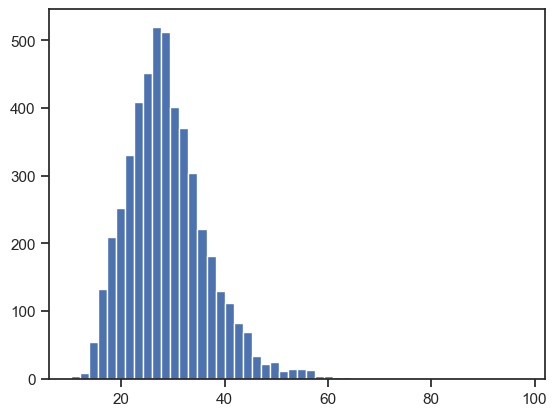

In [121]:
plt.hist(data['bmi'], 50)
plt.show()

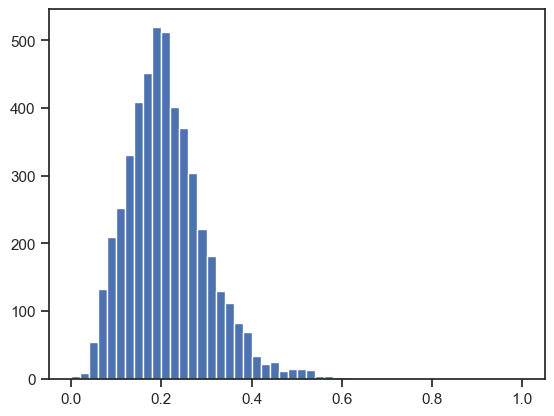

In [122]:
plt.hist(sc1_data, 50)
plt.show()

In [123]:
sc2 = MinMaxScaler()
sc2_data = sc2.fit_transform(data[['avg_glucose_level']])

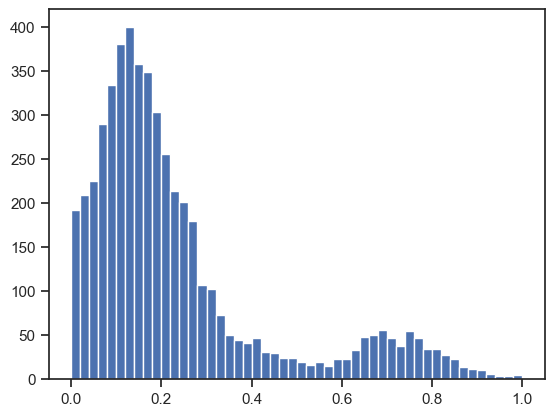

In [124]:
plt.hist(sc2_data, 50)
plt.show()

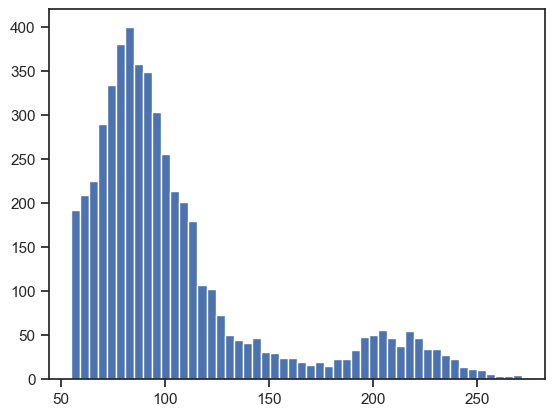

In [125]:
plt.hist(data['avg_glucose_level'], 50)
plt.show()

In [126]:
sc1_2 = StandardScaler()
sc1_2_data = sc1_2.fit_transform(data[['bmi']])

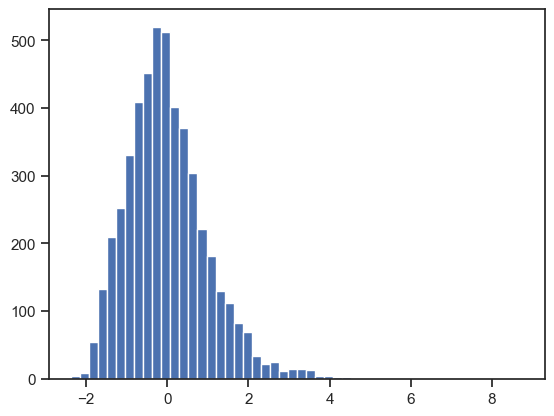

In [127]:
plt.hist(sc1_2_data, 50)
plt.show()

In [128]:
sc2_2 = StandardScaler()
sc2_2_data = sc2_2.fit_transform(data[['avg_glucose_level']])

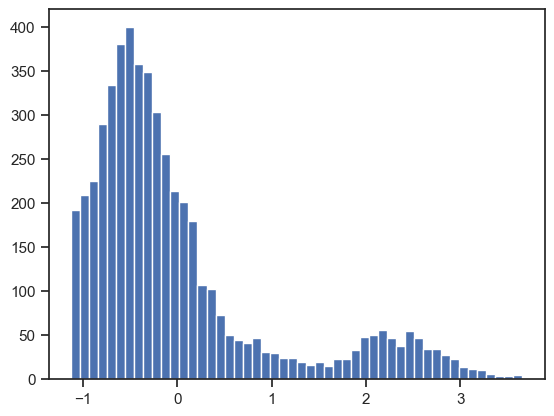

In [129]:
plt.hist(sc2_2_data, 50)
plt.show()